# Import needed modules

In [1]:
# import system libs
import os
import time
import shutil
import pathlib
import itertools

# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


# Create needed functions

## Functions to Create Data Frame from Dataset

#### **Function to split data frame into train, valid, and test**

In [2]:
# Split dataframe to train, valid, and test
def split_data(data_dir, csv_dir):
    
    df = pd.read_csv(csv_dir)
    df.columns = ['filepaths', 'labels' ]
    df['filepaths'] = df['filepaths'].apply(lambda x: os.path.join(data_dir, x))
    
    # Create train df
    strat = df['labels']
    train_df, dummy_df = train_test_split(df,  train_size= 0.8, shuffle= True, random_state= 123, stratify= strat)

    # valid and test dataframe
    strat = dummy_df['labels']
    valid_df, test_df = train_test_split(dummy_df,  train_size= 0.5, shuffle= True, random_state= 123, stratify= strat)

    return train_df, valid_df, test_df

#### Function to generate images from dataframe

In [3]:
def create_gens (train_df, valid_df, test_df, batch_size):
    '''
    This function takes train, validation, and test dataframe and fit them into image data generator, because model takes data from image data generator.
    Image data generator converts images into tensors. '''


    # define model parameters
    img_size = (224, 224)
    channels = 3 # either BGR or Grayscale
    color = 'rgb'
    img_shape = (img_size[0], img_size[1], channels)

    # Recommended : use custom function for test data batch size, else we can use normal batch size.
    ts_length = len(test_df)
    test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
    test_steps = ts_length // test_batch_size

    # This function which will be used in image data generator for data augmentation, it just take the image and return it again.
    def scalar(img):
        return img

    tr_gen = ImageDataGenerator(preprocessing_function= scalar, horizontal_flip= True)
    ts_gen = ImageDataGenerator(preprocessing_function= scalar)

    train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= color, shuffle= True, batch_size= batch_size)

    valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= color, shuffle= True, batch_size= batch_size)

    # Note: we will use custom test_batch_size, and make shuffle= false
    test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= color, shuffle= False, batch_size= test_batch_size)

    return train_gen, valid_gen, test_gen

#### **Function to display data sample**

In [4]:
def show_images(gen):
    '''
    This function take the data generator and show sample of the images
    '''

    # return classes , images to be displayed
    g_dict = gen.class_indices        # defines dictionary {'class': index}
    classes = list(g_dict.keys())     # defines list of dictionary's kays (classes), classes names : string
    images, labels = next(gen)        # get a batch size samples from the generator

    # calculate number of displayed samples
    length = len(labels)        # length of batch size
    sample = min(length, 25)    # check if sample less than 25 images

    plt.figure(figsize= (20, 20))

    for i in range(sample):
        plt.subplot(5, 5, i + 1)
        image = images[i] / 255       # scales data to range (0 - 255)
        plt.imshow(image)
        index = np.argmax(labels[i])  # get image index
        class_name = classes[index]   # get class of image
        plt.title(class_name, color= 'blue', fontsize= 12)
        plt.axis('off')
    plt.show()

#### **Callbacks** 
<br> 
Callbacks : Helpful functions to help optimize model training  <br> 
Examples: stop model training after specfic time, stop training if no improve in accuracy and so on.

In [5]:
class MyCallback(keras.callbacks.Callback):
    def __init__(self, model, patience, stop_patience, threshold, factor, batches, epochs, ask_epoch):
        super(MyCallback, self).__init__()
        # NOTE: in newer Keras (3.x) self.model is a read-only property that Keras
        # fills in automatically once training starts (before on_train_begin runs),
        # so we do NOT assign to it here - we just use the local `model` argument
        # below instead for this one-time setup.
        self.patience = patience # specifies how many epochs without improvement before learning rate is adjusted
        self.stop_patience = stop_patience # specifies how many times to adjust lr without improvement to stop training
        self.threshold = threshold # specifies training accuracy threshold when lr will be adjusted based on validation loss
        self.factor = factor # factor by which to reduce the learning rate
        self.batches = batches # number of training batch to run per epoch
        self.epochs = epochs
        self.ask_epoch = ask_epoch
        self.ask_epoch_initial = ask_epoch # save this value to restore if restarting training

        # callback variables
        self.count = 0 # how many times lr has been reduced without improvement
        self.stop_count = 0
        self.best_epoch = 1   # epoch with the lowest loss
        self.initial_lr = float(tf.keras.backend.get_value(model.optimizer.lr)) # get the initial learning rate and save it
        self.highest_tracc = 0.0 # set highest training accuracy to 0 initially
        self.lowest_vloss = np.inf # set lowest validation loss to infinity initially
        self.best_weights = model.get_weights() # set best weights to model's initial weights (use local `model`, not self.model)
        self.initial_weights = model.get_weights()   # save initial weights if they have to get restored

    # Define a function that will run when train begins
    def on_train_begin(self, logs= None):
#         msg = 'Do you want model asks you to halt the training [y/n] ?'
#         print(msg)
#         ans = input('')
#         if ans in ['Y', 'y']:
#             self.ask_permission = 1
#         elif ans in ['N', 'n']:
#             self.ask_permission = 0
        
        self.ask_permission = 1
        
        msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format('Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor','% Improv', 'Duration')
        print(msg)
        self.start_time = time.time()


    def on_train_end(self, logs= None):
        stop_time = time.time()
        tr_duration = stop_time - self.start_time
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))

        msg = f'training elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds)'
        print(msg)

        # set the weights of the model to the best weights
        self.model.set_weights(self.best_weights)


    def on_train_batch_end(self, batch, logs= None):
        # get batch accuracy and loss
        acc = logs.get('accuracy') * 100
        loss = logs.get('loss')

        # prints over on the same line to show running batch count
        msg = '{0:20s}processing batch {1:} of {2:5s}-   accuracy=  {3:5.3f}   -   loss: {4:8.5f}'.format(' ', str(batch), str(self.batches), acc, loss)
        print(msg, '\r', end= '')


    def on_epoch_begin(self, epoch, logs= None):
        self.ep_start = time.time()


    # Define method runs on the end of each epoch
    def on_epoch_end(self, epoch, logs= None):
        ep_end = time.time()
        duration = ep_end - self.ep_start

        lr = float(tf.keras.backend.get_value(self.model.optimizer.lr)) # get the current learning rate
        current_lr = lr
        acc = logs.get('accuracy')  # get training accuracy
        v_acc = logs.get('val_accuracy')  # get validation accuracy
        loss = logs.get('loss')  # get training loss for this epoch
        v_loss = logs.get('val_loss')  # get the validation loss for this epoch

        if acc < self.threshold: # if training accuracy is below threshold adjust lr based on training accuracy
            monitor = 'accuracy'
            if epoch == 0:
                pimprov = 0.0
            else:
                pimprov = (acc - self.highest_tracc ) * 100 / self.highest_tracc # define improvement of model progres

            if acc > self.highest_tracc: # training accuracy improved in the epoch
                self.highest_tracc = acc # set new highest training accuracy
                self.best_weights = self.model.get_weights() # training accuracy improved so save the weights
                self.count = 0 # set count to 0 since training accuracy improved
                self.stop_count = 0 # set stop counter to 0
                if v_loss < self.lowest_vloss:
                    self.lowest_vloss = v_loss
                self.best_epoch = epoch + 1  # set the value of best epoch for this epoch

            else:
                # training accuracy did not improve check if this has happened for patience number of epochs
                # if so adjust learning rate
                if self.count >= self.patience - 1: # lr should be adjusted
                    lr = lr * self.factor # adjust the learning by factor
                    tf.keras.backend.set_value(self.model.optimizer.lr, lr) # set the learning rate in the optimizer
                    self.count = 0 # reset the count to 0
                    self.stop_count = self.stop_count + 1 # count the number of consecutive lr adjustments
                    self.count = 0 # reset counter
                    if v_loss < self.lowest_vloss:
                        self.lowest_vloss = v_loss
                else:
                    self.count = self.count + 1 # increment patience counter

        else: # training accuracy is above threshold so adjust learning rate based on validation loss
            monitor = 'val_loss'
            if epoch == 0:
                pimprov = 0.0

            else:
                pimprov = (self.lowest_vloss - v_loss ) * 100 / self.lowest_vloss

            if v_loss < self.lowest_vloss: # check if the validation loss improved
                self.lowest_vloss = v_loss # replace lowest validation loss with new validation loss
                self.best_weights = self.model.get_weights() # validation loss improved so save the weights
                self.count = 0 # reset count since validation loss improved
                self.stop_count = 0
                self.best_epoch = epoch + 1 # set the value of the best epoch to this epoch

            else: # validation loss did not improve
                if self.count >= self.patience - 1: # need to adjust lr
                    lr = lr * self.factor # adjust the learning rate
                    self.stop_count = self.stop_count + 1 # increment stop counter because lr was adjusted
                    self.count = 0 # reset counter
                    tf.keras.backend.set_value(self.model.optimizer.lr, lr) # set the learning rate in the optimizer

                else:
                    self.count = self.count + 1 # increment the patience counter

                if acc > self.highest_tracc:
                    self.highest_tracc = acc

        msg = f'{str(epoch + 1):^3s}/{str(self.epochs):4s} {loss:^9.3f}{acc * 100:^9.3f}{v_loss:^9.5f}{v_acc * 100:^9.3f}{current_lr:^9.5f}{lr:^9.5f}{monitor:^11s}{pimprov:^10.2f}{duration:^8.2f}'
        print(msg)

        if self.stop_count > self.stop_patience - 1: # check if learning rate has been adjusted stop_count times with no improvement
            msg = f' training has been halted at epoch {epoch + 1} after {self.stop_patience} adjustments of learning rate with no improvement'
            print(msg)
            self.model.stop_training = True # stop training

#         else:
#             if self.ask_epoch != None and self.ask_permission != 0:
#                 if epoch + 1 >= self.ask_epoch:
#                     msg = 'enter H to halt training or an integer for number of epochs to run then ask again'
#                     print(msg)

#                     ans = input('')
#                     if ans == 'H' or ans == 'h':
#                         msg = f'training has been halted at epoch {epoch + 1} due to user input'
#                         print(msg)
#                         self.model.stop_training = True # stop training

#                     else:
#                         try:
#                             ans = int(ans)
#                             self.ask_epoch += ans
#                             msg = f' training will continue until epoch {str(self.ask_epoch)}'
#                             print(msg)
#                             msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format('Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor', '% Improv', 'Duration')
#                             print(msg)

#                         except Exception:
#                             print('Invalid')

#### **Function to plot history of training**

In [6]:
def plot_training(hist):
    '''
    This function take training model and plot history of accuracy and losses with the best epoch in both of them.
    '''

    # Define needed variables
    tr_acc = hist.history['accuracy']
    tr_loss = hist.history['loss']
    val_acc = hist.history['val_accuracy']
    val_loss = hist.history['val_loss']
    index_loss = np.argmin(val_loss)
    val_lowest = val_loss[index_loss]
    index_acc = np.argmax(val_acc)
    acc_highest = val_acc[index_acc]
    Epochs = [i+1 for i in range(len(tr_acc))]
    loss_label = f'best epoch= {str(index_loss + 1)}'
    acc_label = f'best epoch= {str(index_acc + 1)}'

    # Plot training history
    plt.figure(figsize= (20, 8))
    plt.style.use('fivethirtyeight')

    plt.subplot(1, 2, 1)
    plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
    plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
    plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
    plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
    plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout
    plt.show()


#### **Function to create Confusion Matrix**

In [7]:
def plot_confusion_matrix(cm, classes, normalize= False, title= 'Confusion Matrix', cmap= plt.cm.Blues):
    '''
    This function plot confusion matrix method from sklearn package.
    '''

    plt.figure(figsize= (10, 10))
    plt.imshow(cm, interpolation= 'nearest', cmap= cmap)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation= 45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis= 1)[:, np.newaxis]
        print('Normalized Confusion Matrix')

    else:
        print('Confusion Matrix, Without Normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

# **Model Structure**

#### **Start Reading Dataset**

In [8]:
# NOTE: change these two paths to point at your own dataset before running this cell
data_dir = r"E:\Vedant Giri\Chicken Disease Data\Train"
csv_dir = r"E:\Vedant Giri\Chicken Disease Data\train_data.csv"

# Split the csv into train / validation / test dataframes
train_df, valid_df, test_df = split_data(data_dir, csv_dir)

# Build the three image data generators (train, valid, test) used for training
batch_size = 40
train_gen, valid_gen, test_gen = create_gens(train_df, valid_df, test_df, batch_size)


Found 6453 validated image filenames belonging to 4 classes.
Found 807 validated image filenames belonging to 4 classes.
Found 807 validated image filenames belonging to 4 classes.


#### **Display Image Sample**

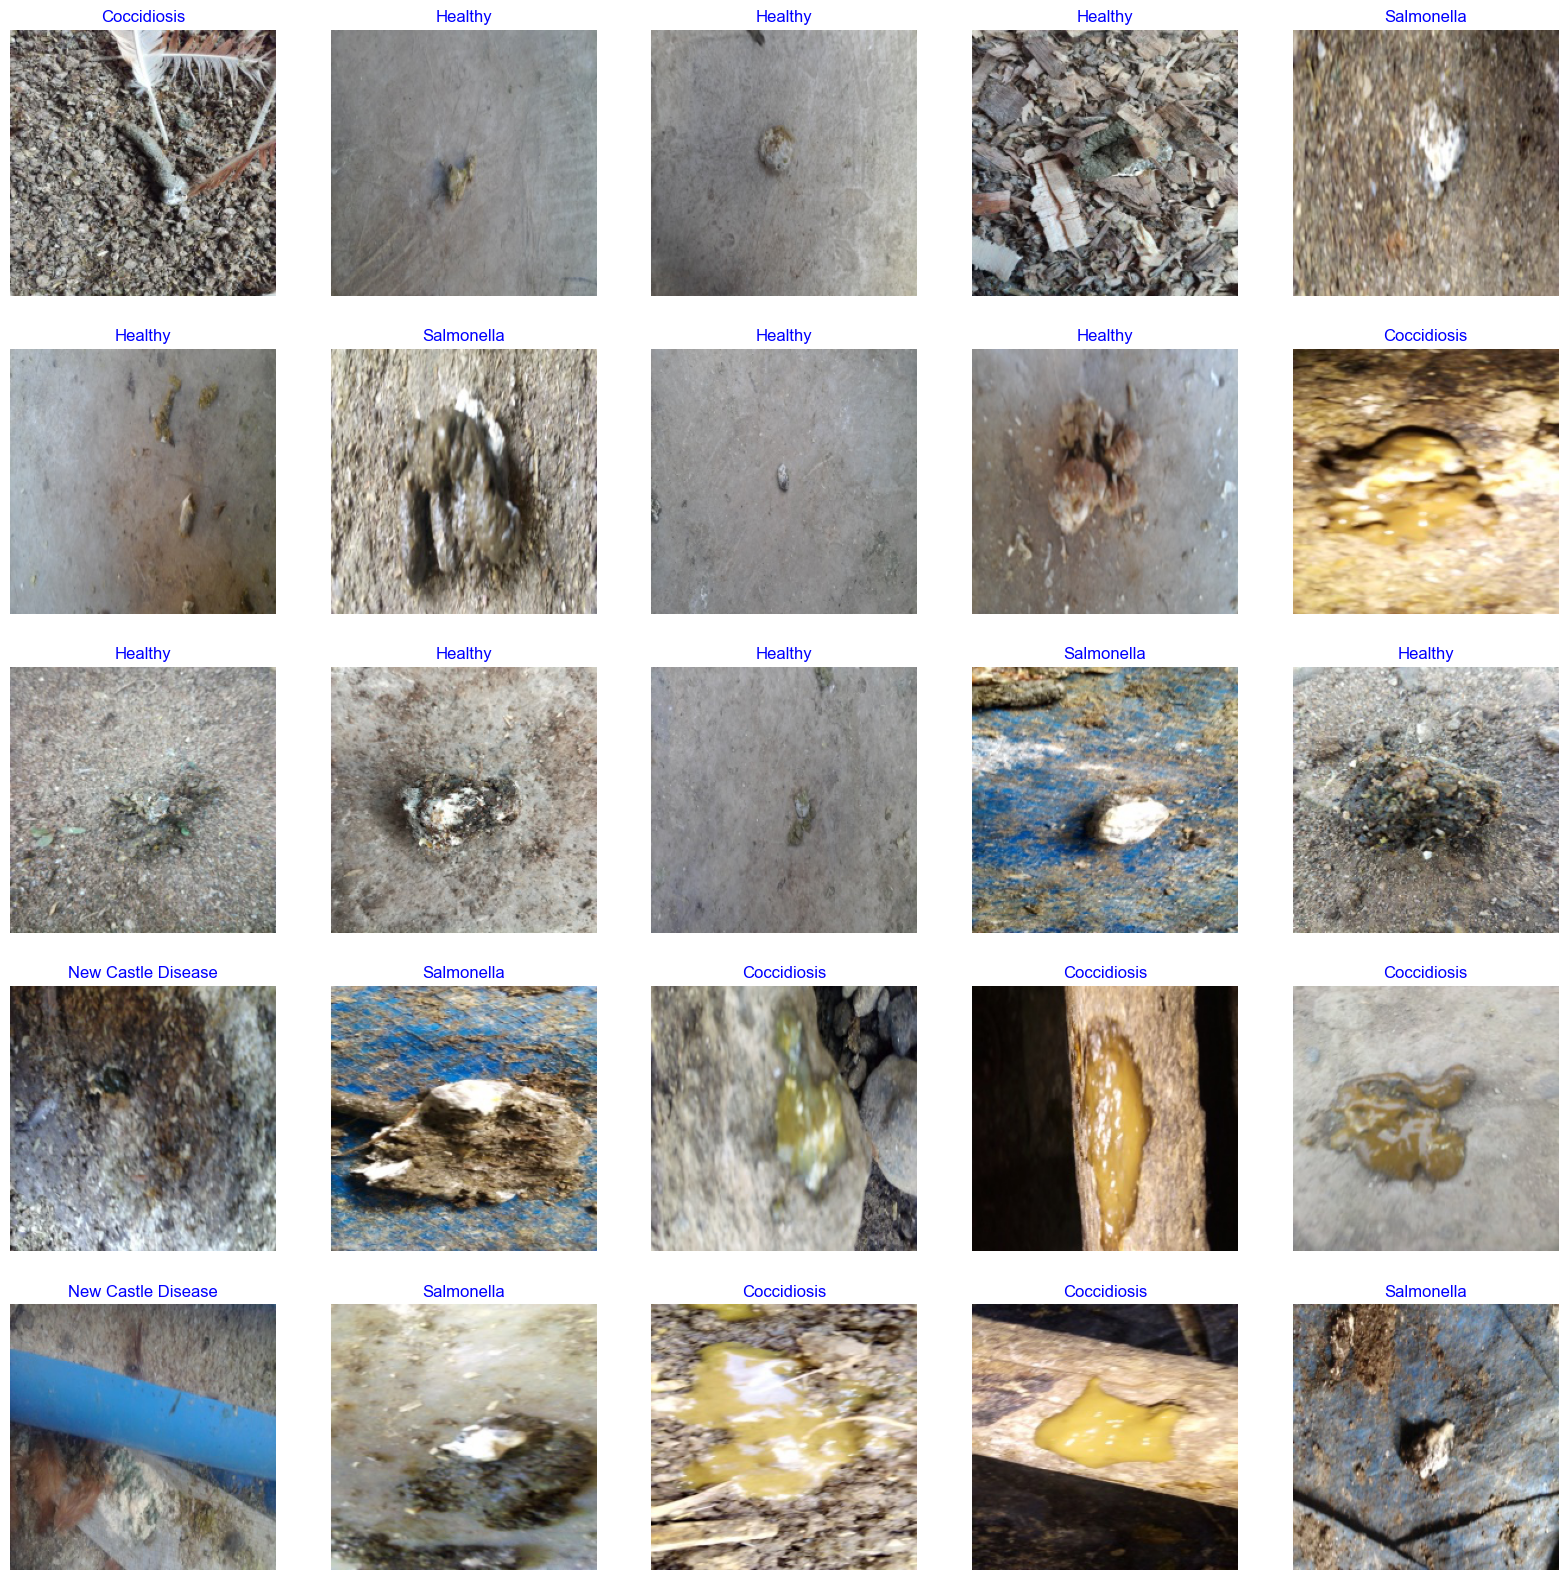

In [9]:
# Preview a batch of training images together with their labels
show_images(train_gen)


#### **Generic Model Creation**

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras import regularizers

# Create Model Structure
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

# Number of output classes
class_count = len(train_gen.class_indices)

# Load pre-trained EfficientNetB3
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=img_shape,
    pooling="max"
)

# Freeze base model for transfer learning
base_model.trainable = False

# Build model
model = Sequential([
    base_model,

    BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),

    Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.016),
        activity_regularizer=regularizers.l1(0.006),
        bias_regularizer=regularizers.l1(0.006)
    ),

    Dropout(0.45, seed=123),

    Dense(class_count, activation="softmax")
])

# Compile model
model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Show summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,184,179 (42.66 MB)

 Trainable params: 397,572 (1.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

#### **Set Callback Parameters**

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

batch_size = 40
epochs = 50

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        verbose=1,
        min_lr=1e-6
    )
]

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=epochs,
    callbacks=callbacks,
    shuffle=False,
    verbose=1
)

Epoch 1/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 507s 3s/step - accuracy: 0.8470 - loss: 6.4419 - val_accuracy: 0.9182 - val_loss: 4.8329 - learning_rate: 0.0010
Epoch 2/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 465s 3s/step - accuracy: 0.9084 - loss: 3.9362 - val_accuracy: 0.9170 - val_loss: 3.0933 - learning_rate: 0.0010
Epoch 3/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 467s 3s/step - accuracy: 0.9236 - loss: 2.5457 - val_accuracy: 0.9294 - val_loss: 2.0345 - learning_rate: 0.0010
Epoch 4/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 477s 3s/step - accuracy: 0.9303 - loss: 1.7200 - val_accuracy: 0.9356 - val_loss: 1.4064 - learning_rate: 0.0010
Epoch 5/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 476s 3s/step - accuracy: 0.9419 - loss: 1.2146 - val_accuracy: 0.9318 - val_loss: 1.0326 - learning_rate: 0.0010
Epoch 6/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 477s 3s/step - accuracy: 0.9419 - loss: 0.9099 - val_accuracy: 0.9294 - val_loss: 0.7922 - learning_rate: 0.0010
Epoch 7/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 485s 3s/step - accuracy: 0.9420 - loss: 0.

#### **Train model**

In [ ]:
# Train the model - "callbacks" now correctly refers to the list created above
history = model.fit(x=train_gen, epochs=epochs, verbose=0, callbacks=callbacks,
                     validation_data=valid_gen, validation_steps=None, shuffle=False)


#### **Display model performance**

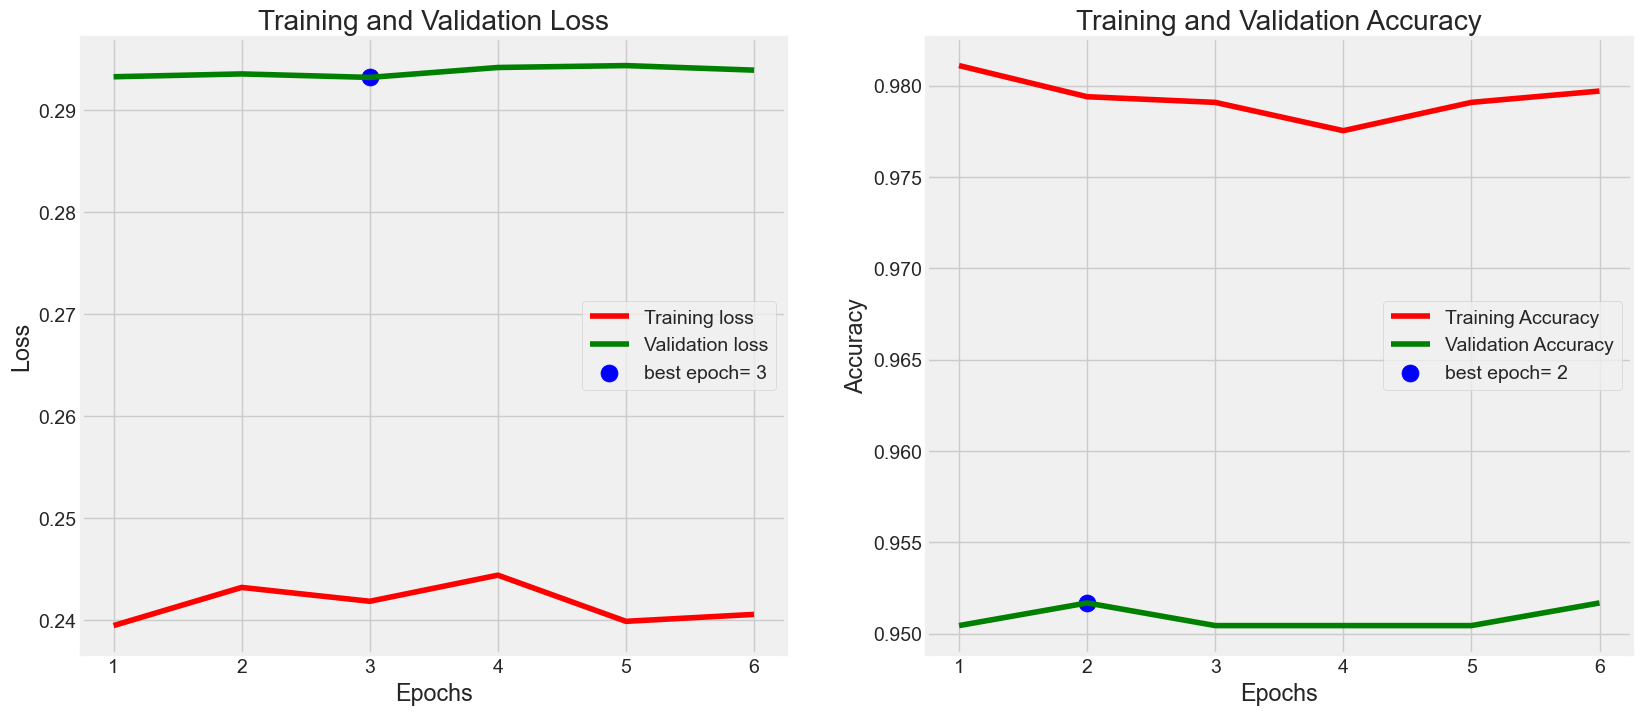

In [13]:
plot_training(history)

# **Evaluate model**

In [14]:
# Recompute a batch size for testing that evenly divides the test set (same rule used in create_gens)
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length % n == 0 and ts_length / n <= 80]))
test_steps = ts_length // test_batch_size

# Evaluate the trained model on all three splits
train_score = model.evaluate(train_gen, steps=test_steps, verbose=1)
valid_score = model.evaluate(valid_gen, steps=test_steps, verbose=1)
test_score = model.evaluate(test_gen, steps=test_steps, verbose=1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])


269/269 ━━━━━━━━━━━━━━━━━━━━ 401s 1s/step - accuracy: 0.9935 - loss: 0.1956
269/269 ━━━━━━━━━━━━━━━━━━━━ 50s 177ms/step - accuracy: 0.9504 - loss: 0.2932
269/269 ━━━━━━━━━━━━━━━━━━━━ 65s 241ms/step - accuracy: 0.9529 - loss: 0.2785
Train Loss:  0.19558246433734894
Train Accuracy:  0.9934914112091064
--------------------
Validation Loss:  0.2932438552379608
Validation Accuracy:  0.9504337310791016
--------------------
Test Loss:  0.278545081615448
Test Accuracy:  0.9529120326042175


# **Get Predictions**

In [15]:
# predict_generator() was removed in newer TensorFlow versions.
# predict() accepts a generator directly and does exactly the same job.
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)   # turn class probabilities into a single predicted class per image
print(y_pred)


269/269 ━━━━━━━━━━━━━━━━━━━━ 68s 228ms/step
[1 0 1 1 1 0 1 1 0 0 0 3 0 0 0 0 1 0 3 3 3 3 3 3 0 3 1 3 1 1 0 3 1 1 1 3 3
 0 0 3 3 0 1 0 2 1 3 0 0 1 0 1 0 1 0 0 0 0 1 1 3 3 3 3 1 0 3 1 3 3 0 1 0 2
 0 2 0 3 1 0 3 1 1 0 0 1 0 0 0 1 1 3 1 0 3 3 1 1 3 1 3 3 3 1 3 3 1 2 3 1 1
 0 0 1 3 0 1 1 3 3 3 1 3 1 1 3 0 1 0 3 1 2 0 0 1 1 1 3 0 3 1 1 3 2 3 1 0 1
 3 0 0 1 1 1 0 0 3 3 1 1 2 3 3 0 1 1 2 1 0 0 1 3 0 0 3 3 1 1 1 1 3 3 0 3 1
 3 0 3 0 0 1 1 0 0 3 1 1 1 3 3 1 3 3 0 0 1 3 3 0 0 3 1 3 1 0 3 0 3 1 3 0 1
 3 3 3 0 0 0 3 1 0 1 3 1 1 1 0 0 3 0 3 3 2 0 0 1 1 0 0 2 0 1 2 3 0 3 1 0 1
 3 0 1 3 0 2 0 1 3 1 0 1 3 3 1 0 1 0 0 0 3 1 1 3 0 0 3 0 1 1 0 3 0 1 0 3 3
 1 1 2 3 0 0 3 1 0 1 2 3 1 0 1 0 0 1 0 1 3 3 1 1 3 1 3 3 1 3 1 1 3 2 3 1 1
 3 1 0 0 0 3 3 1 3 2 2 0 1 3 1 1 1 0 0 0 1 2 1 0 2 3 1 3 1 3 3 0 1 0 3 3 1
 1 0 0 1 3 0 3 3 0 1 0 3 3 3 1 3 1 0 0 0 1 3 3 1 3 0 3 1 1 0 1 1 1 3 2 0 3
 0 3 0 3 1 3 2 3 0 0 0 3 0 3 3 1 1 1 3 3 0 1 3 0 3 3 1 1 0 1 1 3 0 3 1 0 3
 1 0 3 2 0 0 1 2 3 3 2 0 1 0 1 1 3 0 1 1 0 1 3 3 1 1 0 3

#### **Confusion Matrics and Classification Report**

Confusion Matrix, Without Normalization
[[241   5   1   0]
 [  2 233   2   4]
 [  2   6  45   3]
 [  2   9   2 250]]
                    precision    recall  f1-score   support

       Coccidiosis       0.98      0.98      0.98       247
           Healthy       0.92      0.97      0.94       241
New Castle Disease       0.90      0.80      0.85        56
        Salmonella       0.97      0.95      0.96       263

          accuracy                           0.95       807
         macro avg       0.94      0.92      0.93       807
      weighted avg       0.95      0.95      0.95       807



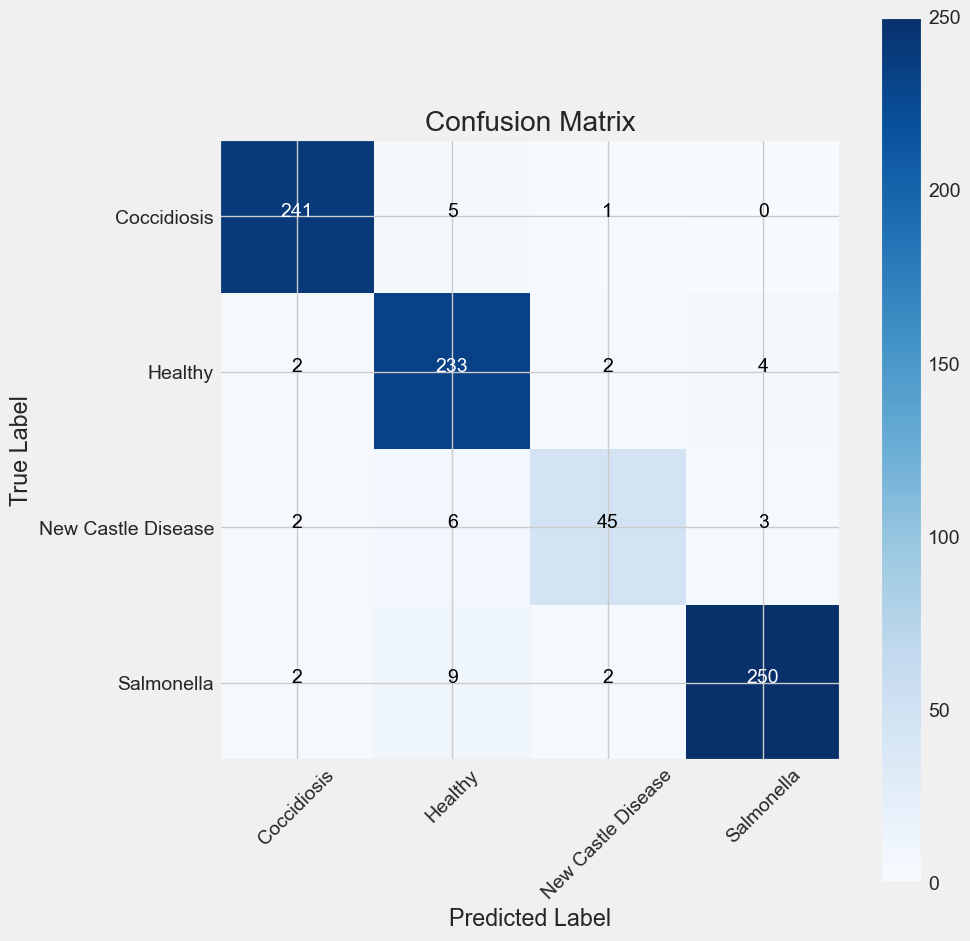

In [16]:
# Class names, in the same order used by the generator
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Build and plot the confusion matrix (true labels vs predicted labels)
cm = confusion_matrix(test_gen.classes, y_pred)
plot_confusion_matrix(cm=cm, classes=classes, title='Confusion Matrix')

# Precision / recall / F1-score per class
print(classification_report(test_gen.classes, y_pred, target_names=classes))


#### **Save model**

In [18]:
# Simple, readable names for the saved files (avoids relying on internal model attributes)
model_name = 'EfficientNetB3'
subject = 'Chicken Disease'
acc = test_score[1] * 100
save_path = ''

# Save the full model (architecture + weights)
save_id = f'{model_name}-{subject}-{acc:.2f}.h5'
model_save_loc = os.path.join(save_path, save_id)
model.save(model_save_loc)
print(f'model was saved as {model_save_loc}')

# Save only the weights (handy if you just want to reload them into the same architecture later)
# NOTE: newer Keras requires the filename to end in ".weights.h5" exactly, not just ".h5"
weight_save_id = f'{model_name}-{subject}.weights.h5'
weights_save_loc = os.path.join(save_path, weight_save_id)
model.save_weights(weights_save_loc)
print(f'weights were saved as {weights_save_loc}')

model was saved as EfficientNetB3-Chicken Disease-95.29.h5
weights were saved as EfficientNetB3-Chicken Disease.weights.h5


#### **Generate CSV files containing classes indicies & image size**

In [19]:
# Save the class-index mapping and expected image size to a CSV,
# so this info can be reused later at inference time without retraining.
class_dict = train_gen.class_indices
img_size = train_gen.image_shape
height = []
width = []
for _ in range(len(class_dict)):
    height.append(img_size[0])
    width.append(img_size[1])

Index_series = pd.Series(list(class_dict.values()), name='class_index')
Class_series = pd.Series(list(class_dict.keys()), name='class')
Height_series = pd.Series(height, name='height')
Width_series = pd.Series(width, name='width')
class_df = pd.concat([Index_series, Class_series, Height_series, Width_series], axis=1)
csv_name = f'{subject}-class_dict.csv'
csv_save_loc = os.path.join(save_path, csv_name)
class_df.to_csv(csv_save_loc, index=False)
print(f'class csv file was saved as {csv_save_loc}')


class csv file was saved as Chicken Disease-class_dict.csv


In [20]:
import pickle

# --- Build a simple "pipeline" object that bundles everything the app needs to predict ---
# Note: Keras models don't pickle reliably, so we save the model itself with model.save()
# (already done earlier) and pickle only the light-weight info needed to load it + preprocess.

class ChickenDiseasePipeline:
    def __init__(self, model_path, class_indices, img_size):
        self.model_path = model_path          # path to the saved .h5/.keras model file
        self.class_indices = class_indices     # {class_name: index} mapping
        self.idx_to_class = {v: k for k, v in class_indices.items()}
        self.img_size = img_size               # (height, width)
        self._model = None                     # loaded lazily so pickle stays small/fast

    def _load_model(self):
        if self._model is None:
            import tensorflow as tf
            self._model = tf.keras.models.load_model(self.model_path)
        return self._model

    def predict(self, image_path):
        import numpy as np
        from tensorflow.keras.preprocessing import image as keras_image

        model = self._load_model()

        # preprocess the image the same way training data was preprocessed
        img = keras_image.load_img(image_path, target_size=self.img_size)
        img_array = keras_image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

        preds = model.predict(img_array)
        pred_idx = int(np.argmax(preds, axis=1)[0])
        pred_class = self.idx_to_class[pred_idx]
        confidence = float(np.max(preds))

        return pred_class, confidence


# --- Create and save the pipeline ---
pipeline = ChickenDiseasePipeline(
    model_path=model_save_loc,                       # from the earlier save cell
    class_indices=train_gen.class_indices,            # class name -> index mapping
    img_size=train_gen.image_shape[:2]                 # (height, width) used during training
)

pkl_path = 'chicken_disease_pipeline.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(pipeline, f)

print(f'Pipeline saved as {pkl_path}')

Pipeline saved as chicken_disease_pipeline.pkl


In [27]:
with open('chicken_disease_pipeline.pkl', 'rb') as f:
    pipeline = pickle.load(f)

pred_class, confidence = pipeline.predict("E:\Vedant Giri\Chicken Disease Data\Train\pcrcocci.156.jpg")
print(pred_class, confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Coccidiosis 0.993344783782959
